# Testing mixture model
To investigate whether the lack of offset responses is due to the fact that a PFC ignition was present in only some of the trials, we use a gaussian mixture model. A gaussian mixture model has for objective to determine whether an observed  distribution was generated by a mixture of two (or more) processes rather than a single one. In our case, a process giving rise to some of the observation would be a ignition in the PFC, while another would be the lack of ignition in the PFC. To test whether this is the case, we will be fitting a mixture model with two components:

$$y ~ w_0 * \mathcal{N}(\mu_0, \sigma_0) + w1 * mathcal{N}(\mu_1, \sigma_1)$$

with the added constraint that $\mu_1 > \mu_0$ so that $\mu_1$ corresponds to the trial with ignition (where we would expect larger activation). We will take $y$ to be the mean HGP activity from 0.2-0.6s following stimulus offset. In addition, we will fit a competing model:

$$y ~ \mathcal{N}(\mu, \sigma)$$

To determine whether a subset of the trials showed ignition, we will compare the two vs. one component model using bayesian model comparison. If the two components model wins, we have evidence for the interpretation that a subset of the trial showed ignition.

But before we can get there, we need to validate our Gaussian mixture model algorithm. For that, we will perform two important checks:
1. Simulate data in which activation is generated by two distinct processes to see whether our algorithm can detect the ground truth
2. Use onset related activation of real iEEG data where we know that a different exists between task relevant and irrelevant (where we would expect our algorithm to detect two components) to test whether our algorithm can pick it up as well

## Ground truth simulation
For our simulation to be as close as possible to real data, we will generate a time series of temporally autocorrelated random data, on top of which we will convolve a gamma function for some of the trials, simulating what an ignition on a subset of trials should look like:

In [28]:
from pathlib import Path
%matplotlib inline
from scipy.stats import gamma as gamma_dist
from scipy.stats import zscore
import scipy
import mne
import arviz as az
import mne
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cog_ieeg import plot_ieeg_image
from mne.baseline import rescale
from offset_analysis import compute_bad_amp_per_channel, mixture_model, plot_mixture_fit, print_rejection_summary, compare_models_loo

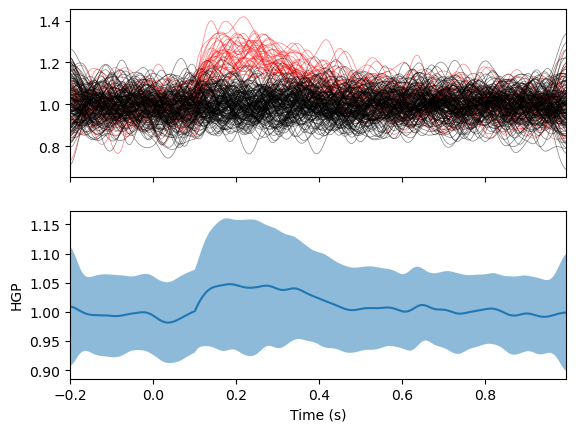

In [29]:
# Set activation parameters
mu = 1   # Mean of random noise, offset to 1 because HGP
sd = 1/4  # Standard deviation

# Set trial parameters
n_trials = 200
tmin = -0.2
tmax = 1.0
sfreq = 200
t = np.arange(tmin, tmax, 1/sfreq)
# Set ignition parameters
ignition_kernel = gamma_dist(a=2, scale=0.1).pdf(t[t>=0])  # Ignition kernel
ignition_kernel /= ignition_kernel.max()
ignition_onset = 0.1  # Time of ignition onset
stick = np.zeros(t.shape)  # Stick for ignition onset
stick[np.where([t>=ignition_onset])[1][0]] = 1
p_ignition = 0.2 # Ignition in say 20% of the trials
ignition_effect_size = 1

# Simulate single trial data:
data = []
ignited = []
for trial in range(n_trials):
    # Generate the data
    # 1. Generate temporally correlated time series (gaussian kernel)
    y = scipy.ndimage.gaussian_filter1d(np.random.normal(mu, sd, t.shape), 4)
    # 2. Convolved with a gaussian kernel if necessary:
    if np.random.binomial(1, p_ignition) == 1:
        y += np.convolve(stick, ignition_kernel, mode="full")[: t.shape[0]] * (ignition_effect_size * sd)
        ignited.append(1)
    else:
        ignited.append(0)
    # Append the data>
    data.append(y)

# Convert to a numpy array:
data = np.array(data)
# Plot the data:
fig, ax = plt.subplots(2, sharex=True)
ax[0].plot(t, data[np.array(ignited).astype(bool), :].T, 'r', linewidth=0.5, alpha=0.5);
ax[0].plot(t, data[np.array(ignited).astype(bool) == False, :].T, 'k', linewidth=0.5, alpha=0.5);
ax[1].plot(t, np.mean(data, axis=0))
ax[1].fill_between(t, np.mean(data, axis=0) - np.std(data, axis=0), np.mean(data, axis=0) + np.std(data, axis=0), alpha=.5)
ax[1].set_xlim(t[0], t[-1]);
ax[1].set_xlabel('Time (s)');
ax[1].set_ylabel('HGP');

We can now derive our measure of activation on the simulated data to show the distribution

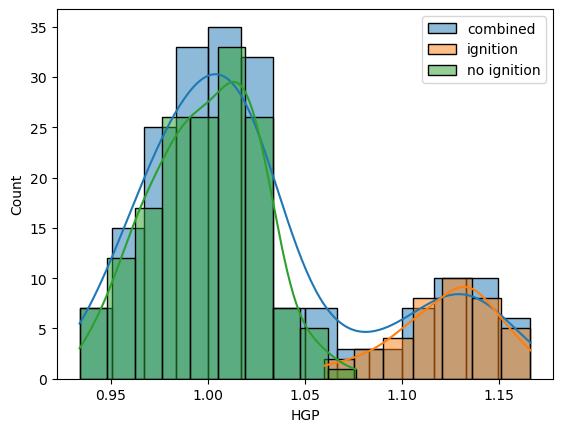

In [30]:
activation_window = [0.2, 0.6]
y = np.mean(data[:, (activation_window[0] <= t) & (t <= activation_window[1])], axis=-1)
fig, ax = plt.subplots()
sns.histplot(y, alpha=0.5, kde=True, ax=ax, label='combined');
sns.histplot(y[np.array(ignited).astype(bool)], alpha=0.5, kde=True, ax=ax, label='ignition');
sns.histplot(y[np.array(ignited).astype(bool) == False], alpha=0.5, kde=True, ax=ax, label='no ignition');
ax.set_xlabel('HGP');
ax.legend();

As expected, we see that the overall distribution looks quite spread out. The underlying activation of ignited trials is larger than that of none ignited trials. We can now test our bayesian mixture model to see whether it is able to pick up on the two distinct underlying processes. 

In [31]:
# Test mixture model:

# Fit models
idata1 = mixture_model(y, 2, draws=1000, tune=1000, chains=4)  # Model with 2 components
idata0 = mixture_model(y, 1, draws=1000, tune=1000, chains=4)  # Model with 2 components


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, delta, sigma, w]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Output()

Just to make sure nothing went wrong with the sampling and that the retrieved parameters make sense, we can plot the chains with the expected values:

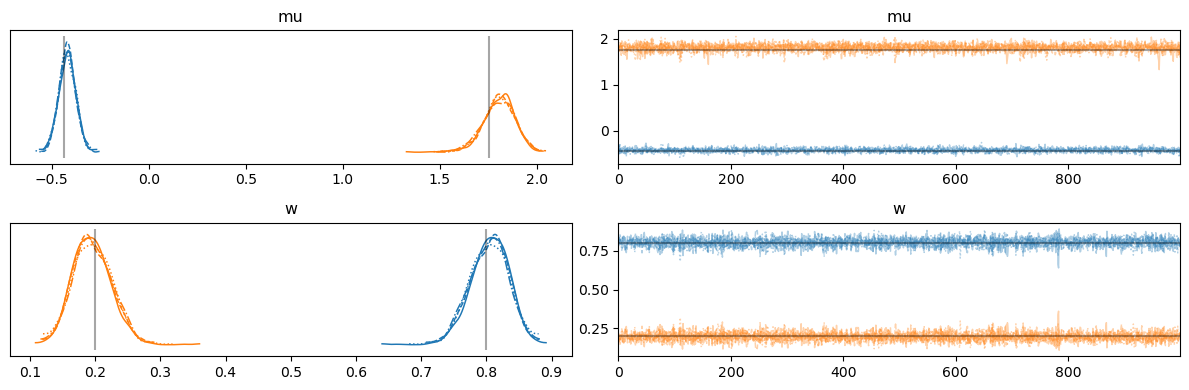

In [32]:
y_zscore = zscore(y)
az.plot_trace(idata1, var_names=["mu", 'w'], lines=[("mu", {}, [np.mean(y_zscore[np.array(ignited).astype(bool)==False]), np.mean(y_zscore[np.array(ignited).astype(bool)])]), ("w", {}, [1-p_ignition, p_ignition])]); 
plt.tight_layout()

That seems about righ: the extimated $w$ parameters match the proportions of ignited and non ignited trials and the mean amplitude of each group also matches. And the chains seem quite stable without any divergences, so we can now move on to the model comparison:

In [ ]:
# Compare:
loo0, loo1, cmp, wins, delta_elpd, delta_se, pareto_k = compare_models_loo(idata0, idata1, print_summary=True)


Result of one vs. two components model comparison:
   Two components model LOO=-236.15624517860186
   One components model LOO=-285.7725611827853
   Delta elpd=49.61631600418343
   Delta se=14.743402900365302
   Normalized Delta elpd (> 2 = evidence for 2 comp)=3.3653232119807344
Two components model wins? True


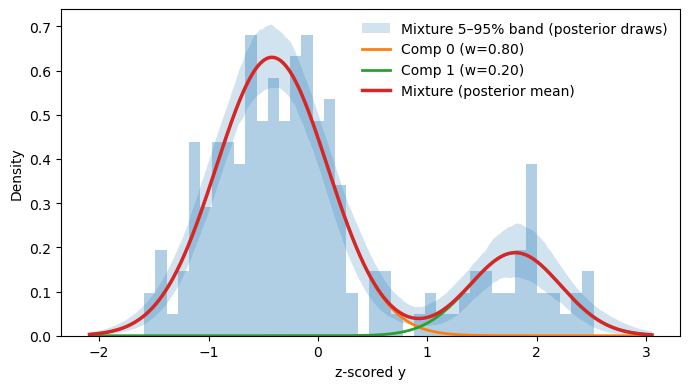

In [34]:
if wins:
    fig, ax = plot_mixture_fit(idata1, y)
else:
    fig, ax = plot_mixture_fit(idata0, y)

As we can see, the algorithm is able to determine that the data come from two separate processes. The proportions of the two processes match roughly what we have estimated (20% of the trials with ignition), validating our pipeline. The last step in making sure it works as intended consists in checking that it doesn't detect effects where there are none (i.e. specificity). For that, we can simply simulate data with the ignition proportion set to 0 and see which of the two models win:

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, delta, sigma, w]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Result of one vs. two components model comparison:
   Two components model LOO=-287.1585027663295
   One components model LOO=-285.7331450269145
   Delta elpd=-1.4253577394150057
   Delta se=13.977215922836862
   Normalized Delta elpd (> 2 = evidence for 2 comp)=-0.10197722831813492
Two components model wins? False


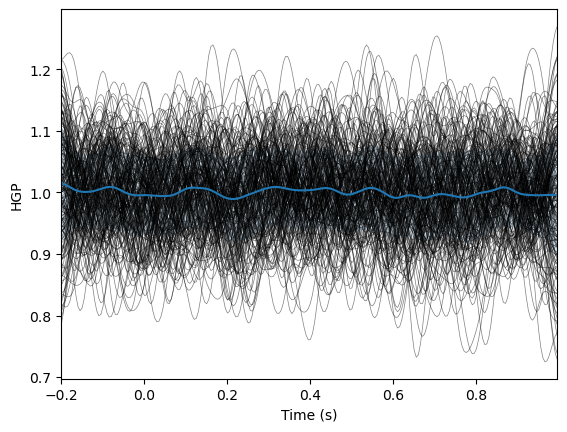

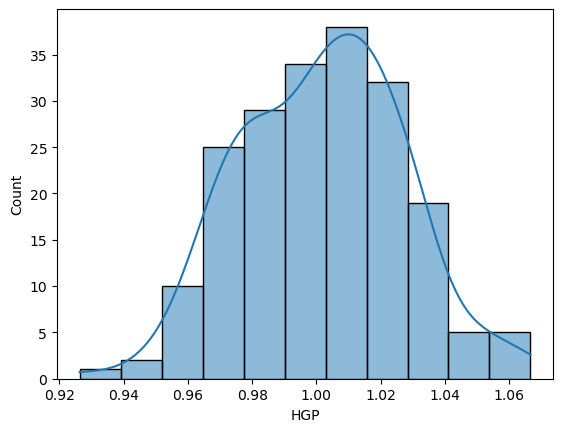

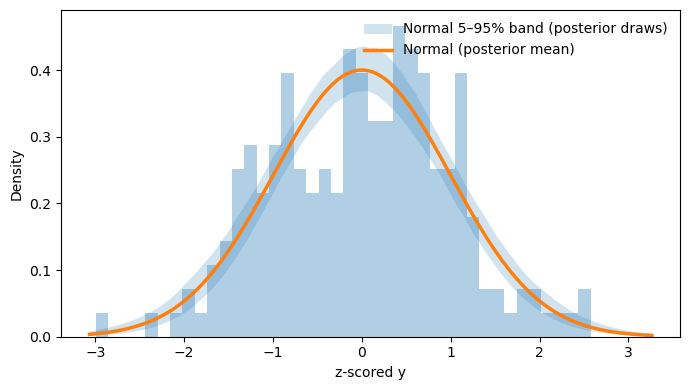

In [ ]:
p_ignition = 0 # Ignition 0% of the trials

# Simulate single trial data:
data = []
ignited = []
for trial in range(n_trials):
    # Generate the data
    # 1. Generate temporally correlated time series (gaussian kernel)
    y = scipy.ndimage.gaussian_filter1d(np.random.normal(mu, sd, t.shape), 4)
    # 2. Convolved with a gaussian kernel if necessary:
    if np.random.binomial(1, p_ignition) == 1:
        y += np.convolve(stick, ignition_kernel, mode="full")[: t.shape[0]] * (ignition_effect_size * sd)
        ignited.append(1)
    else:
        ignited.append(0)
    # Append the data>
    data.append(y)

# Convert to a numpy array:
data = np.array(data)
# Plot the data:
fig, ax = plt.subplots()
ax.plot(t, data[np.array(ignited).astype(bool), :].T, 'r', linewidth=0.5, alpha=0.5);
ax.plot(t, data[np.array(ignited).astype(bool) == False, :].T, 'k', linewidth=0.5, alpha=0.5);
ax.plot(t, np.mean(data, axis=0))
ax.fill_between(t, np.mean(data, axis=0) - np.std(data, axis=0), np.mean(data, axis=0) + np.std(data, axis=0), alpha=.2)
ax.set_xlim(t[0], t[-1]);
ax.set_xlabel('Time (s)');
ax.set_ylabel('HGP');

# Plot the distribution:
activation_window = [0.2, 0.6]
y = np.mean(data[:, (activation_window[0] <= t) & (t <= activation_window[1])], axis=-1)
fig, ax = plt.subplots()
sns.histplot(y, alpha=0.5, kde=True, ax=ax)
ax.set_xlabel('HGP');

# =======================================================
# Modelling the data:
# Fit models
idata0 = mixture_model(y, 1, draws=1000, tune=1000, chains=4)
idata1 = mixture_model(y, 2, draws=1000, tune=1000, chains=4)

# Compare
loo0, loo1, cmp, wins, delta_elpd, delta_se, pareto_k = compare_models_loo(idata0, idata1, print_summary=True)
if wins:
    plot_mixture_fit(idata1, y)
else:
    plot_mixture_fit(idata0, y)

As expected, the model with only one component wins, indicating that our model is specific, i.e. it does not detect effects when there are none. So by now, we know that our model is both sensitive and specific, which is what we want. Now of course, the sensitivity of our model is depending on the data themselves. First, the data need to be sufficiently large to draw robust inference. In addition, if the distribution of the two underlying is too similar (i.e. closely overlapping distribution), our model will have a harder time to discriminate between them and would need much more data to be able to do so than if the two distribution are very different (a clear bimodal split). In addition, if one of the two processes occur only in a very small fraction of trials, it will also be more difficult for the model to detect the two processes. After all we are dealing with a statistical model, so the inference we can draw are of course contingent on the signal to noise ratio in the data and to the sample size, nothing new there.

## Testing the model on real data

Now, as a final check, we can make sure that our model is capable of detecing effects in the real data. So as to not bias our analysis, we will perform this check on data in a separate ROI, investigating a different effect that we know is present. For some electrodes in the ventral temporal cortex, we observe (unsurprisingly) an effect of category, such that some electrodes only get activated when a face was presented, and not when the other categories were presented (objects, letters and symbols). We will pick an electrode in which this effect is really clear. Since the task was balanced across categories, we know that we have roughly 1/4th of the trial in which we have activation, and the rest none. We therefore expect the model with two components to win and to return a w~0.25 for the first component, and 0.75 for comp 0 (give or take because of artifact rejection). Let's give that a go:

Reading /home/alexlepauvre/Documents/Github/Reconstructed_time_analysis/data/bids/derivatives/preprocessing/sub-CF113/ses-1/ieeg/epoching/high_gamma/sub-CF113_ses-1_task-Dur_desc-epoching_ieeg-epo.fif ...
    Found the data of interest:
        t =    -750.00 ...    2500.00 ms
        0 CTF compensation matrices available
Adding metadata with 9 columns
1440 matching events found
No baseline correction applied
0 projection items activated


/home/alexlepauvre/Documents/Github/Reconstructed_time_analysis/offset_analysis.py:379: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = ep.get_data()  # (n_epochs, n_ch, n_times)


G3: rejected 323/1440 (22.4%)
G1: rejected 317/1440 (22.0%)
G2: rejected 270/1440 (18.8%)
G4: rejected 208/1440 (14.4%)
G5: rejected 184/1440 (12.8%)
DAMT 5: rejected 161/1440 (11.2%)
DAMT 2: rejected 157/1440 (10.9%)
RAT 1: rejected 144/1440 (10.0%)
DAI4: rejected 140/1440 (9.7%)
G10: rejected 134/1440 (9.3%)
G9: rejected 134/1440 (9.3%)
RIT2: rejected 110/1440 (7.6%)
DAI3: rejected 103/1440 (7.2%)
RIT3: rejected 75/1440 (5.2%)
DAMT 6: rejected 69/1440 (4.8%)
DPMT6: rejected 63/1440 (4.4%)
RIT1: rejected 55/1440 (3.8%)
G26: rejected 50/1440 (3.5%)
G25: rejected 47/1440 (3.3%)
DPMT5: rejected 40/1440 (2.8%)
G19: rejected 39/1440 (2.7%)
DPMT8: rejected 37/1440 (2.6%)
DAMT 8: rejected 34/1440 (2.4%)
DAMT 7: rejected 33/1440 (2.3%)
G18: rejected 33/1440 (2.3%)
DPMT7: rejected 32/1440 (2.2%)
G6: rejected 30/1440 (2.1%)
RIT4: rejected 30/1440 (2.1%)
DPMT4: rejected 28/1440 (1.9%)
RPF1: rejected 25/1440 (1.7%)
DPMT3: rejected 25/1440 (1.7%)
G27: rejected 20/1440 (1.4%)
G12: rejected 18/1440 

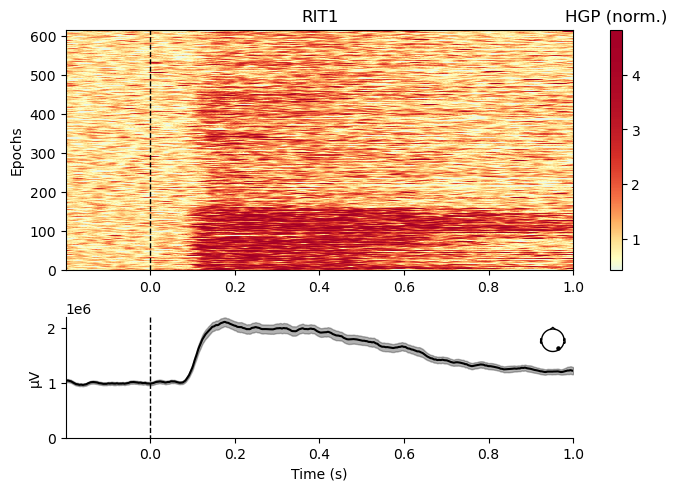

In [36]:

data_root = bids_root = "./data/bids"
# Load epochs data:
epochs_file = Path(data_root, "derivatives", "preprocessing", f"sub-{'CF113'}", 
            "ses-1", 'ieeg', 'epoching', 'high_gamma',
            f"sub-{'CF113'}_ses-1_task-Dur_desc-epoching_ieeg-epo.fif")

# picks = epochs.ch_names # get_roi_channels(ev.cog_bids_root, 'CF104', "1", "destrieux", pfc_roi)
epochs = mne.read_epochs(epochs_file).pick(['ecog', 'seeg'], exclude='bads')
picks = ['RIT1']
# Remove outliers:
bad_amp, good_idx_by_ch, _ = compute_bad_amp_per_channel(epochs, tmin=-0.3, tmax=0.6, z_thr=10)
print_rejection_summary(bad_amp, epochs.ch_names)
# Baseline correction
baseline = (-0.3, 0)
epochs.apply_function(rescale, times=epochs.times, baseline=baseline, mode='ratio', verbose='ERROR');

for pick in picks:
    onset_data_clean = epochs.copy().crop(-0.2, 1)[good_idx_by_ch[pick]]["stimulus onset/Relevant non-target", "stimulus onset/Irrelevant"]
    order = list(onset_data_clean.metadata.copy().reset_index(drop=True).sort_values(['category', 'task_relevance', 'duration', 'identity']).index)
    fig = plot_ieeg_image(onset_data_clean, pick, show=True, order=order,
        units="HGP (norm.)", scalings=1, cmap="RdYlBu_r",
        center=1, ylim_prctile=99, logistic_cmap=True, ci=0.95);
    ax = fig[0].axes[1]
    ax.set_ylim([0.7*10e6, ax.get_ylim()[1]]);

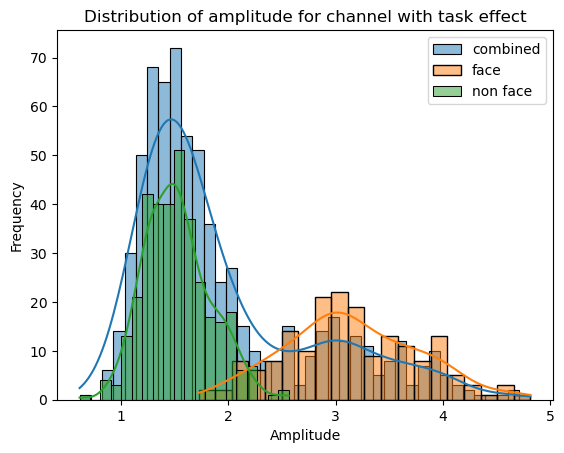

In [37]:
# Set relevant channel:
channel = picks[0]
# Get clean data:
onset_data_clean = epochs.copy().crop(-0.2, 1).pick(channel)[good_idx_by_ch[pick]][["stimulus onset"]]
# Compute the mean activation in each trial:
amp_all = np.mean(np.squeeze(onset_data_clean.get_data(tmin=0.2, tmax=0.5, copy=False)), axis=-1)
amp_face = np.mean(np.squeeze(onset_data_clean['face'].get_data(tmin=0.2, tmax=0.5, copy=False)), axis=-1)
amp_rest = np.mean(np.squeeze(onset_data_clean['object', 'letter', 'false font'].get_data(tmin=0.2, tmax=0.5, copy=False)), axis=-1)
# Plot histogram:
fig, ax = plt.subplots()
sns.histplot(amp_all, bins=40, alpha=0.5, kde=True, ax=ax, label='combined');
sns.histplot(amp_face, bins=20, alpha=0.5, kde=True, ax=ax, label='face');
sns.histplot(amp_rest, bins=20, alpha=0.5, kde=True, ax=ax, label='non face');
ax.set_ylabel('Frequency')
ax.set_xlabel('Amplitude')
ax.set_title('Distribution of amplitude for channel with task effect')
ax.legend()
plt.show()

We can see that the distribution is clearly bimodal (as one would expect based on the raster plot). Now let's see if the model comparison returns what we expect:

In [ ]:
# Fit models
idata0 = mixture_model(amp_all, 1, draws=1000, tune=1000, chains=4)
idata1 = mixture_model(amp_all, 2, draws=1000, tune=1000, chains=4)

# Compare
loo0, loo1, cmp, wins, delta_elpd, delta_se, pareto_k = compare_models_loo(idata0, idata1, print_summary=True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu0, delta, sigma, w]
/home/alexlepauvre/miniforge3/envs/prp_experiment/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


Output()


Result of one vs. two components model comparison:
   Two components model LOO=-771.695350245109
   One components model LOO=-987.0099215749226
   Delta elpd=215.3145713298136
   Delta se=32.41342218069369
   Normalized Delta elpd (> 2 = evidence for 2 comp)=6.64275959907932
Two components model wins? True


Unsurprisingly, the two components model wins. Just to be extra sure, we can plot the chains:

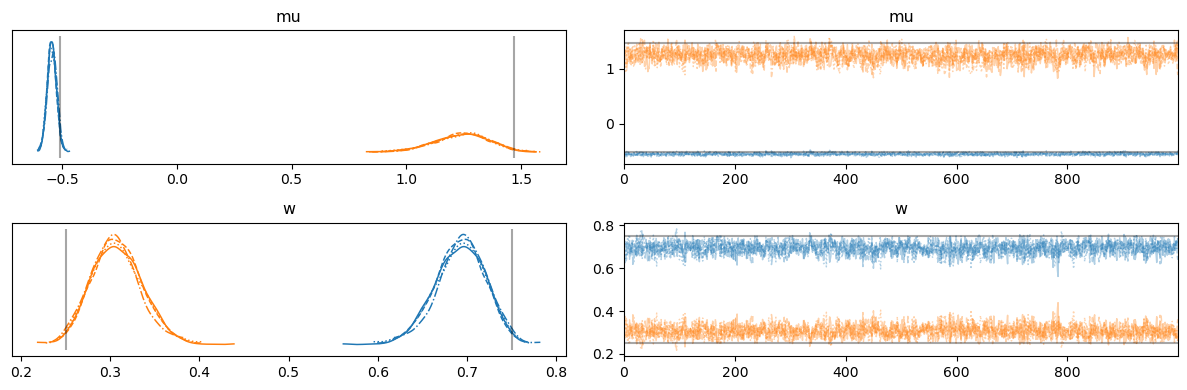

In [39]:
amp_zscore = zscore(amp_all)
mu_face = np.mean(amp_zscore[onset_data_clean.metadata['category'] == 'face'])
mu_rest = np.mean(amp_zscore[onset_data_clean.metadata['category'] != 'face'])
az.plot_trace(idata1, var_names=["mu", 'w'], lines=[("mu", {}, [mu_face, mu_rest]), ("w", {}, [0.75, 0.25])]); 
plt.tight_layout()


Now, let's perform the posterior predictive checks, to make sure that the model is able to characterize the observed data well:

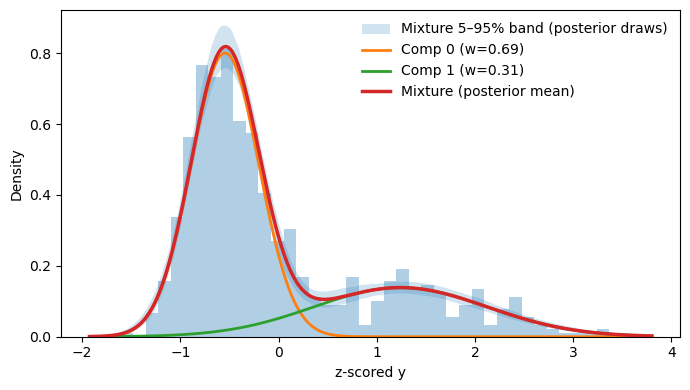

In [40]:
fig, ax = plot_mixture_fit(idata1, amp_all,
                        title=None,
                        do_zscore=True,
                        bins=40,
                        n_posterior_draws=200,
                        seed=0)

The overall distribution is quite well captured by the model, validating the posterior predictive checks. The w parameter doesn't exactly match our data cateogries distribution (25% faces). That's to be expected because eventhough we know that faces generally elicit a strong response is this electrode, there is always some noise, such that some faces trials might not have such a large activation (if participants blinked at the moment of stimulus onset for example) and the other way around, non face trials might have larger activation, blurring the boundary. And are probably mixing up a lot of processes as we have a lot of additional conditions we are not investigating here but that are still mixed up in our trials. But overlall, these results validate that our algorithm is capable of detecing when the data are generated from two different processes.

We can now safely apply it to the data in the prefrontal cortex to see whether the lack of ignition observed across trials is due to the fact that only a subset of the trials are affected. 